In [9]:
import numpy as np
import matplotlib.pyplot as plt

from skimage.data import shepp_logan_phantom
from skimage.transform import radon, rescale

# Note: you need to install scikit-image

In the following block of code we load a phantom object to image (the Shepp-Logan phantom), look at the object, and its sinogram

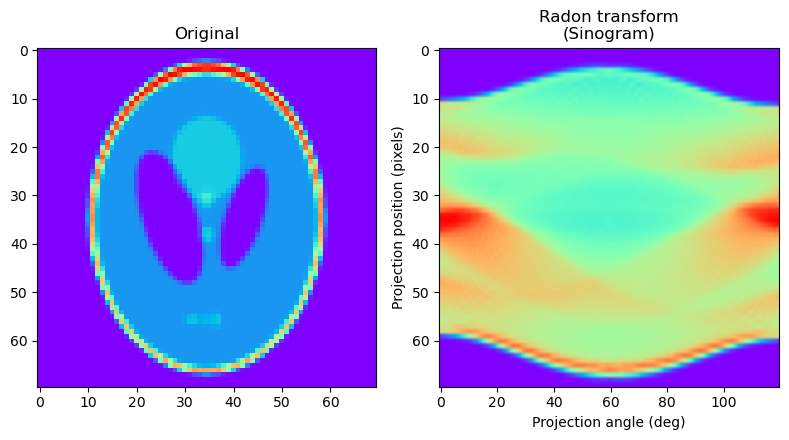

In [10]:
# Set the number of pixels in the object
num_pixels_x = 70
num_pixels_y = num_pixels_x

cmap = "rainbow"

# Set the number of angles for the Radon transform
num_angles = 120
angles = np.linspace(0, 180, num_angles)

# Generate image
image = shepp_logan_phantom()
image = rescale(image, scale=num_pixels_x/400, mode='reflect', channel_axis=None)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4.5))

# Plot image
ax1.set_title("Original")
ax1.imshow(image, cmap=cmap)

# Plot sinogram
sinogram = radon(image, theta=angles)
ax2.set_title("Radon transform\n(Sinogram)")
ax2.set_xlabel("Projection angle (deg)")
ax2.set_ylabel("Projection position (pixels)")
ax2.imshow(
    sinogram,
    cmap=cmap,
    aspect='auto',
)

fig.tight_layout()
plt.show()


What happens inside the call 'sinogram = radon(image, theta=angles)' is essentially matrix-vector $A * image\_vec$ multiplication. The following function explicitely makes the matrix $A$:

In [6]:
def explicit_radon_transform(num_pixels_x, num_pixels_y, num_angles):
    # Angles equidistant spaced from 0 to 180 degrees
    angles = np.linspace(0, 180, num_angles)

    # Get number of detectors
    zero_image = np.zeros((num_pixels_y, num_pixels_x))
    empty_sinogram = radon(zero_image, theta=angles)
    num_detectors = empty_sinogram.shape[0]

    # Get dimensions of matrix A
    m = num_detectors*num_angles
    n = num_pixels_x * num_pixels_y

    # Initialise A
    A_radon = np.zeros((m, n))

    # Fill in the columns of A one-by-one
    pixel_index = 0
    for pixel_number_y in range(num_pixels_y):
        for pixel_number_x in range(num_pixels_y):
            zero_image[pixel_number_y, pixel_number_x] = 1

            sinogram = radon(zero_image, theta=angles)

            A_radon[:, pixel_index] = sinogram.reshape(m,)

            zero_image[pixel_number_y, pixel_number_x] = 0
            pixel_index = pixel_index + 1

    return A_radon   



We explicitely make $A$; this might take a while depending on the number of pixels and angles. Note that the second dimension of $A$ is the total number of pixels. Make sure you check that you have an overdetermined matrix. If $n>m$, increase the number of angles.

In [7]:
# Form A
A_radon = explicit_radon_transform(num_pixels_x, num_pixels_y, num_angles)
print('The dimensions of A are ', A_radon.shape)

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\skimage\transform\radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(


The dimensions of A are  (8400, 4900)


In [8]:
print(type(A_radon))

<class 'numpy.ndarray'>


We check whether we got the same sinogram

In [ ]:
# Get number of detectors from the size of A
num_detectors = int(A_radon.shape[0]/num_angles)

# Vectorize the image
image_vec = image.reshape(num_pixels_y * num_pixels_x, 1)

# Make vectorized sinogram
my_sinogram_vec = np.dot(A_radon, image_vec)

# Reshape
my_sinogram = my_sinogram_vec.reshape(num_detectors, num_angles)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 4.5))
# Plot the image
ax1.set_title("Original")
ax1.imshow(image, cmap=plt.cm.Greys_r)

# Plot the orginal sinogram
ax2.set_title("Sinogram from radon function")
ax2.set_xlabel("Projection angle (deg)")
ax2.set_ylabel("Projection position (pixels)")
ax2.imshow(
    sinogram,
    cmap=plt.cm.Greys_r,
    aspect='auto',
)

# Plot the new sinogram
ax3.set_title("Sinogram from our A*x")
ax3.set_xlabel("Projection angle (deg)")
ax3.set_ylabel("Projection position (pixels)")
ax3.imshow(
    my_sinogram,
    cmap=plt.cm.Greys_r,
    aspect='auto',
)

fig.tight_layout()
plt.show()    